# Feature Selection

This notebook reuses the already preprocessed data from `Preprocessment.ipynb` and applies:
1. Pearson correlation (numeric features vs target)
2. Logistic Regression
3. Random Forest feature importance

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

TARGET_COL = "y"
RANDOM_STATE = 42

In [12]:
X_train = pd.read_csv(Path(r"data/X_train_processed.csv"))
X_test = pd.read_csv(Path(r"data/X_test_processed.csv"))
y_train = pd.read_csv(Path(r"data/y_train.csv"))
y_test = pd.read_csv(Path(r"data/y_test.csv"))

y_train = y_train.squeeze("columns")
y_test = y_test.squeeze("columns")

y_train = y_train.map({"yes": 1, "no": 0})
y_test = y_test.map({"yes": 1, "no": 0})


#drop the duration column
X_train.drop(columns=["duration"], inplace=True)
X_test.drop(columns=["duration"], inplace=True)


print(f"Train preprocessed shape: {X_train.shape}")
print(f"Test preprocessed shape:  {X_test.shape}")

Train preprocessed shape: (36168, 46)
Test preprocessed shape:  (9043, 46)


## 1) Pearson Correlation

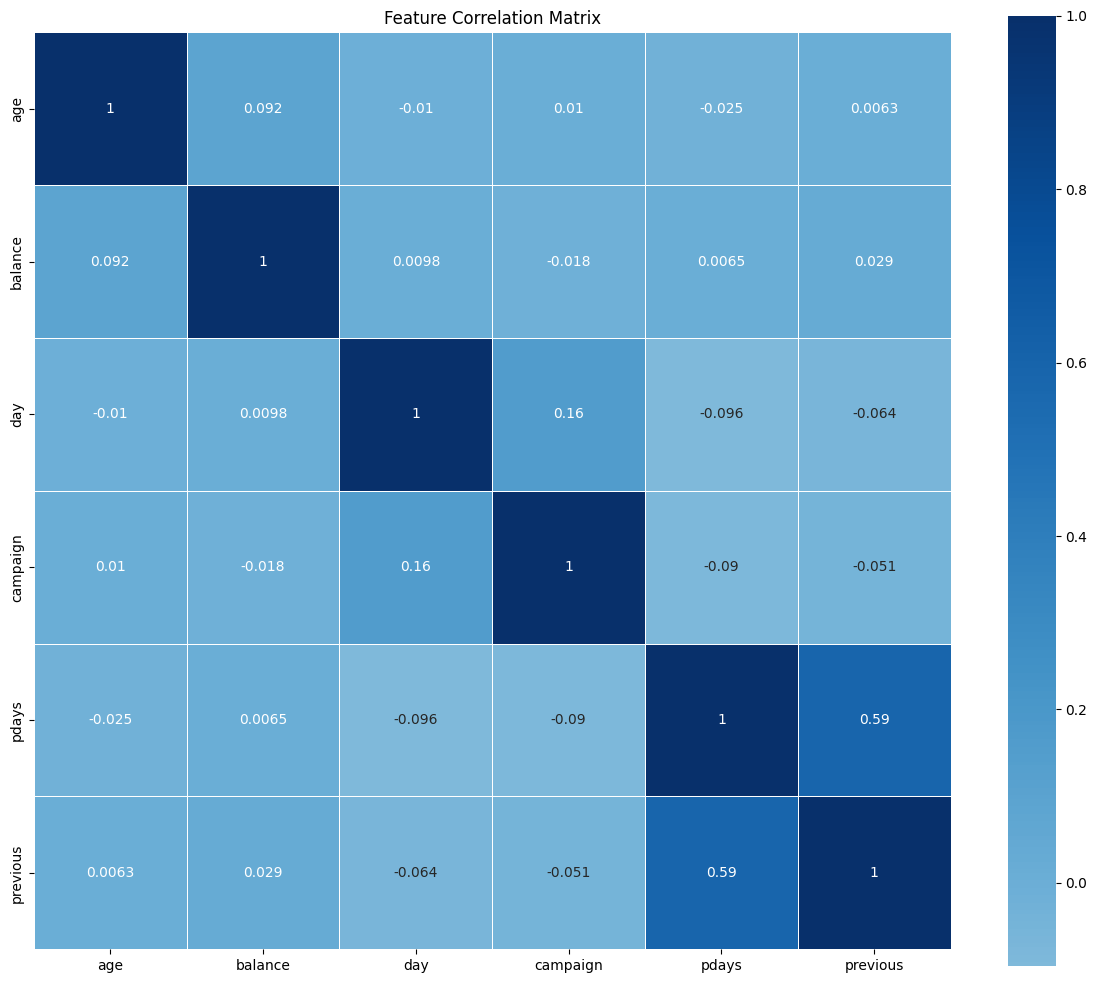

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# correlation matrix between features
corr_map = X_train[numeric_cols].corr()

# filter the variables with valuue_counts length greater than 2
filtered_cols = [col for col in numeric_cols if X_train[col].nunique() > 2]
filtered_corr_map = X_train[filtered_cols].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    filtered_corr_map,
    cmap="Blues",
    center=0,
    square=True,
    annot=True,
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [13]:
# combine features with target
corr_df = X_train.copy()
corr_df["target"] = y_train

# calculate Pearson correlation with target
pearson_corr = corr_df.corr()["target"].drop("target")

# Create a clean dataframe
pearson_corr_df = pd.DataFrame({
    "pearson_corr": pearson_corr,
    "abs_pearson_corr": pearson_corr.abs()
}).sort_values("abs_pearson_corr", ascending=False)

# Show top features
print("Top features by Pearson correlation with target:")
display(pearson_corr_df.head(20))


Top features by Pearson correlation with target:


,pearson_corr,abs_pearson_corr
poutcome_success,0.305847,0.305847
poutcome_failure,-0.232563,0.232563
housing_no,0.139432,0.139432
housing_yes,-0.139432,0.139432
month_oct,0.128644,0.128644
previous,0.127844,0.127844
month_mar,0.127495,0.127495
month_sep,0.117247,0.117247
month_may,-0.103630,0.103630
pdays,0.098250,0.098250


In [ ]:
## 2) Logistic Regression
for c in [1, 0.5, 0.1, 0.05, 0.01]:
    model = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=c,
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)

    coefficients = pd.Series(model.coef_[0], index=X_train.columns)

    selected_features = coefficients[coefficients != 0].index.tolist()

    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]

    #print selected features with the length of the list and the value of c
    print(f"C: {c} - Selected features: {len(selected_features)} - {selected_features}")


c:\Users\gusta\Desktop\hackaton-NTT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gusta\Desktop\hackaton-NTT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


C: 1 - Selected features: 39 - ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_divorced', 'marital_married', 'education_primary', 'education_secondary', 'default_yes', 'housing_no', 'housing_yes', 'loan_yes', 'contact_telephone', 'month_apr', 'month_aug', 'month_dec', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_failure', 'poutcome_other', 'poutcome_success']


c:\Users\gusta\Desktop\hackaton-NTT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gusta\Desktop\hackaton-NTT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


C: 0.5 - Selected features: 38 - ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_divorced', 'marital_married', 'education_primary', 'education_secondary', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'month_apr', 'month_aug', 'month_dec', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_failure', 'poutcome_other', 'poutcome_success']
C: 0.1 - Selected features: 37 - ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_divorced', 'marital_married', 'education_primary', 'education_secondary', 'default_yes', 'housing_yes', 'loan_yes'

c:\Users\gusta\Desktop\hackaton-NTT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gusta\Desktop\hackaton-NTT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\gusta\Desktop\hackaton-NTT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1

C: 0.05 - Selected features: 29 - ['day', 'campaign', 'pdays', 'job_blue-collar', 'job_housemaid', 'job_retired', 'job_services', 'job_student', 'job_technician', 'marital_divorced', 'marital_married', 'education_primary', 'education_secondary', 'housing_yes', 'loan_yes', 'month_apr', 'month_aug', 'month_dec', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_failure', 'poutcome_other', 'poutcome_success']
C: 0.01 - Selected features: 19 - ['day', 'job_blue-collar', 'job_retired', 'marital_married', 'education_primary', 'education_secondary', 'housing_yes', 'loan_yes', 'contact_cellular', 'month_apr', 'month_aug', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_oct', 'poutcome_failure', 'poutcome_other', 'poutcome_success']
(36168, 19)
(9043, 19)


c:\Users\gusta\Desktop\hackaton-NTT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gusta\Desktop\hackaton-NTT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## 3) Random Forest Importance

In [ ]:
# One-hot encode categoricals for Random Forest
X_train_encoded = X_train.copy()

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced",
)
rf.fit(X_train_encoded, y_train)

rf_importance_encoded = pd.Series(rf.feature_importances_, index=X_train_encoded.columns).sort_values(ascending=False)
rf_importance_encoded.head(15)

c:\Users\gusta\Desktop\hackaton-NTT\.venv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


balance                0.169756
age                    0.146507
day                    0.130425
campaign               0.070035
pdays                  0.046435
poutcome_success       0.028578
previous               0.026444
poutcome_failure       0.022111
housing_no             0.019733
housing_yes            0.016789
month_may              0.015384
month_apr              0.015100
job_technician         0.013854
education_secondary    0.013679
job_blue-collar        0.013561
dtype: float64

In [10]:
TOP_K_RF = 15
selected_by_rf = rf_importance.head(TOP_K_RF).index.tolist()

print(f"Random Forest selected top-{TOP_K_RF} features: {len(selected_by_rf)}")
selected_by_rf

Random Forest selected top-15 features: 15


['balance',
 'age',
 'day',
 'campaign',
 'pdays',
 'poutcome_success',
 'previous',
 'poutcome_failure',
 'housing_no',
 'housing_yes',
 'month_may',
 'month_apr',
 'job_technician',
 'education_secondary',
 'job_blue-collar']

## Final Selected Features